# ML Project 1
## Author: Matvey Fedortsov

# 1. Цель проекта

Цель данного проекта - построить прогностическую модель для определения победителя в поединках UFC. Мы будем использовать исторические данные по бойцам и поединкам для выявления ключевых факторов, влияющих на исход боя.

**Задачи:**
*   **Исследовательский анализ данных (EDA):** Понимание структуры данных, выявление пропусков, выбросов и распределений признаков.
*   **Предобработка данных:** Очистка данных, обработка пропусков, создание новых признаков (Feature Engineering).
*   **Обучение моделей машинного обучения:** Использование различных алгоритмов (Логистическая регрессия, Случайный лес, Градиентный бустинг) для построения классификаторов.
*   **Оптимизация гиперпараметров:** Применение библиотеки Optuna для поиска оптимальных параметров моделей.
*   **Оценка моделей:** Сравнение производительности моделей с использованием метрик Accuracy, ROC-AUC и LogLoss.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import optuna

Датасет: https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset/data


# 2. Обзор данных

Используемый датасет содержит обширную информацию о поединках UFC, включая статистику бойцов (рост, размах рук, возраст, стойка, победные/проигрышные серии), коэффициенты букмекеров, результаты ударов, тейкдаунов, сабмишенов и многое другое.

**Ключевые аспекты данных:**
*   **Размерность:** Более 7000 строк и 100+ столбцов.
*   **Пропуски:** Значительное количество пропусков, особенно в специфических категориях рейтингов и некоторых статистических показателях.
*   **Целевая переменная:** `Winner` (победитель боя: Красный угол или Синий угол).

In [ ]:
df = pd.read_csv('ufc-master.csv')
df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


In [ ]:
print(f" Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f" Типы данных:\n{df.dtypes.value_counts()}")
print(f"\n Топ-10 столбцов с пропусками:\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

 Размер датасета: 7177 строк, 118 столбцов
 Типы данных:
float64    60
int64      43
object     14
bool        1
Name: count, dtype: int64

 Топ-10 столбцов с пропусками:
B_Women's Featherweight_rank    7176
R_Women's Featherweight_rank    7168
B_Pound-for-Pound_rank          7096
B_Women's Flyweight_rank        7092
R_Women's Flyweight_rank        7066
B_Women's Strawweight_rank      7063
B_Women's Bantamweight_rank     7057
B_Welterweight_rank             7046
B_Light Heavyweight_rank        7044
B_Featherweight_rank            7043
dtype: int64


In [ ]:
# Ищем столбец, содержащий 'Red', 'Blue' или 'neither'
target_candidates = [col for col in df.columns if df[col].isin(['Red', 'Blue', 'neither', 'Draw']).any()]

winner_col = target_candidates[0]
# Убираем ничьи и No Contest для бинарной классификации
df = df[~df[winner_col].isin(['neither', 'Draw', 'NC'])].copy()
df['winner'] = (df[winner_col] == 'Red').astype(int)
print(f"✅ Целевая переменная создана из столбца '{winner_col}' (1=Red, 0=Blue)")

print(f"\n Баланс классов:\n{df['winner'].value_counts(normalize=True).map('{:.1%}'.format)}")

✅ Целевая переменная создана из столбца 'Winner' (1=Red, 0=Blue)

 Баланс классов:
winner
1    57.8%
0    42.2%
Name: proportion, dtype: object


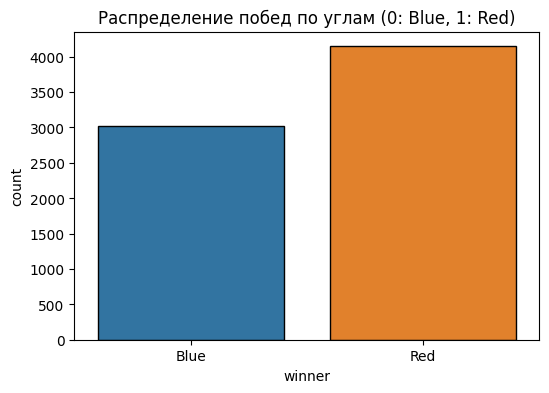

In [ ]:
### Промежуточный вывод: Обзор и очистка данных
Начальный обзор данных выявил более 7000 записей со 118 столбцами, включая значительное количество пропусков, особенно в столбцах рейтингов. Мы успешно определили целевую переменную `Winner`, преобразовали ее в бинарный формат (`1=Red, 0=Blue`) и отметили небольшой дисбаланс классов, где бойцы "Красного угла" выигрывают чаще (57.8%). Визуализации подтвердили распределение побед и наличие пропусков.

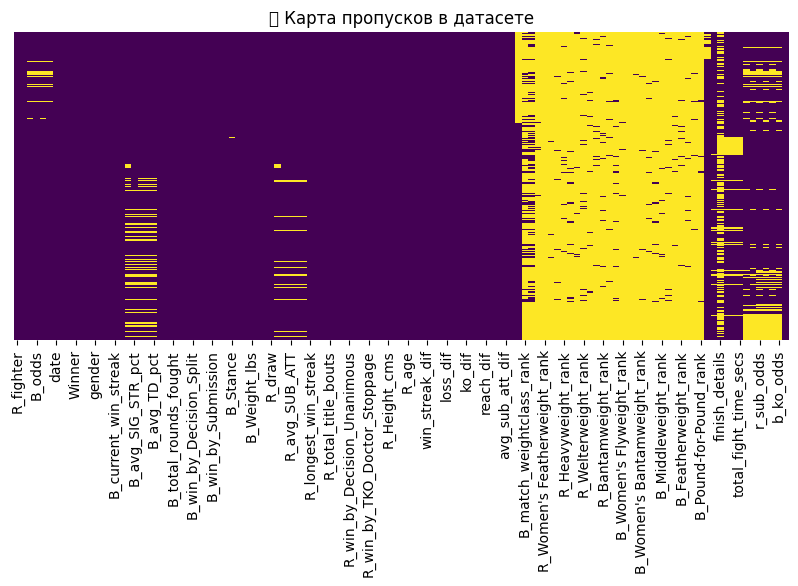

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('🗺️ Карта пропусков в датасете')
plt.show()

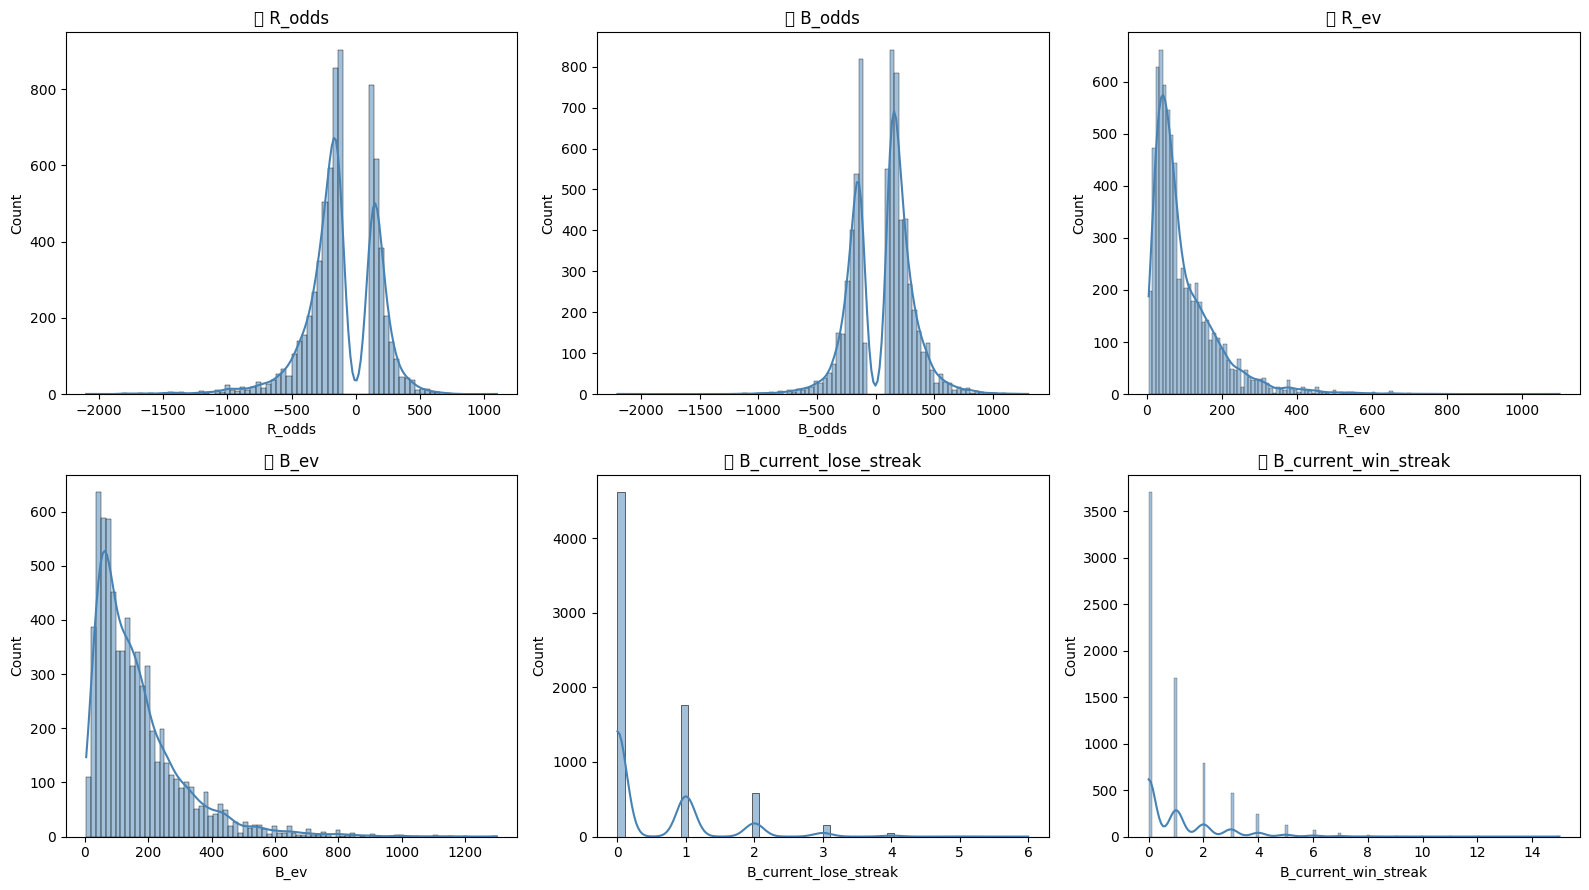

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
# Исключаем целевую и потенциальные ID/годы для чистоты EDA
num_cols = [c for c in num_cols if c not in ['winner', 'year', 'month'] and df[c].nunique() > 5]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols[:6]):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'📈 {col}')
plt.tight_layout()
plt.show()

# 3. Предобработка данных и Генерация признаков

На этом этапе мы готовим данные для моделирования.

**Основные шаги:**
1.  **Обработка целевой переменной:** Создание бинарной целевой переменной `winner` (1, если победил боец из красного угла; 0, если из синего угла).
2.  **Обработка пропусков:**
    *   Для столбцов, связанных с рейтингами бойцов, создаются индикаторные переменные `_not_ranked`, а сами пропуски заполняются специфическим значением (например, 999).
    *   Остальные числовые пропуски заполняются медианой, категориальные - модой.
3.  **Создание разностных признаков (Feature Engineering):** Поскольку данные представлены парами `R_` (Red fighter) и `B_` (Blue fighter) для многих статистик, мы создаем новые признаки, представляющие разницу между этими показателями (например, `diff_odds`, `diff_age` и т.д.). Это помогает модели сосредоточиться на относительных преимуществах бойцов.
4.  **Отбор признаков:** Используем Mutual Information и Permutation Importance для оценки значимости признаков и формирования итогового набора данных для обучения моделей.

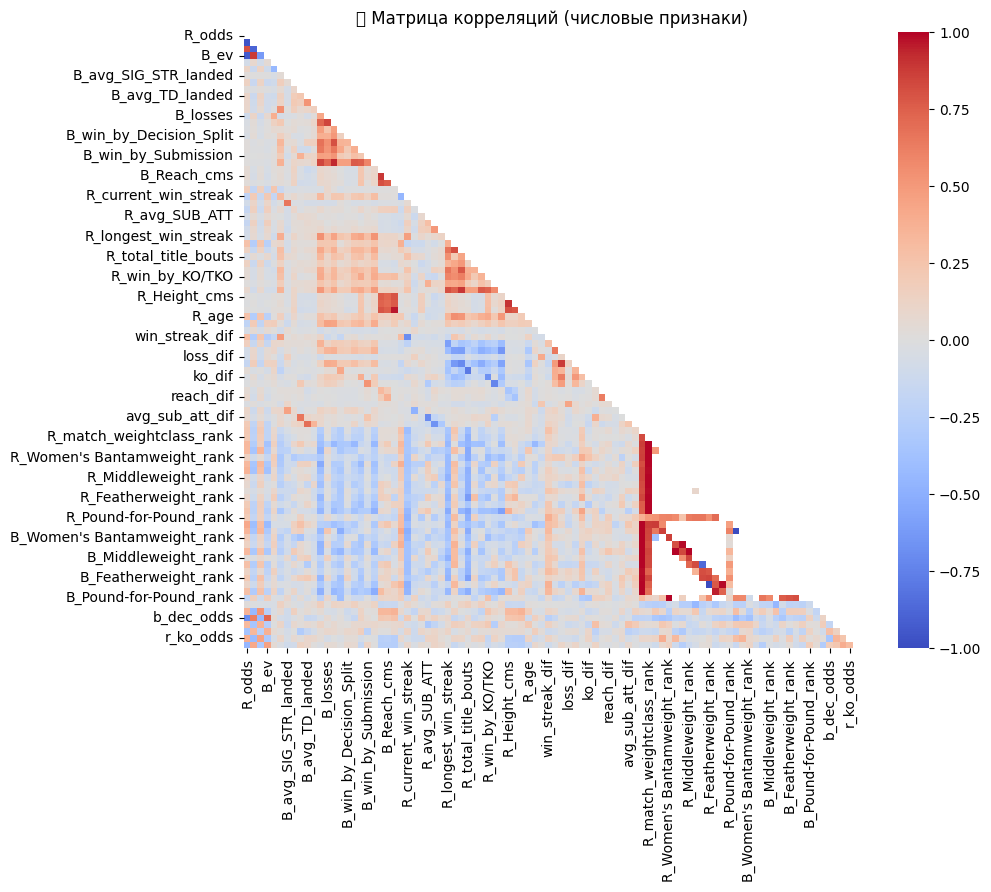

In [ ]:
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('🔗 Матрица корреляций (числовые признаки)')
plt.show()

In [ ]:
# 1. Считаем количество пропусков в каждом столбце
missing_counts = df.isnull().sum()

# 2. Считаем долю пропусков в процентах
missing_percent = (missing_counts / len(df)) * 100

# 3. Формируем сводную таблицу
missing_info = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent
})

# 4. Выводим только столбцы с пропусками, отсортированные по убыванию
display(missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

,Missing_Count,Missing_Percent
B_Women's Featherweight_rank,7171,99.986057
R_Women's Featherweight_rank,7163,99.874512
B_Pound-for-Pound_rank,7091,98.870608
B_Women's Flyweight_rank,7087,98.814835
R_Women's Flyweight_rank,7061,98.452315
B_Women's Strawweight_rank,7058,98.410485
B_Women's Bantamweight_rank,7052,98.326827
B_Welterweight_rank,7041,98.173452
B_Light Heavyweight_rank,7040,98.159509
B_Featherweight_rank,7038,98.131623


In [ ]:
df_processed = df.copy()

# 1. Находим все колонки с рейтингами
rank_columns = [col for col in df_processed.columns if 'rank' in col.lower()]

# 2. Создаём индикаторы not_ranked ПЕРЕД конвертацией в numeric
# Индикатор = 1, если было пропущенное значение ИЛИ нечисловое значение
for col in rank_columns:
    indicator_col = f'{col}_not_ranked'
    # Сначала пробуем конвертировать в число, невалидные значения станут NaN
    numeric_vals = pd.to_numeric(df_processed[col], errors='coerce')
    # Индикатор: 1 = был пропуск или невалидное значение
    df_processed[indicator_col] = numeric_vals.isna().astype(int)

# 3. Конвертируем рейтинги в числовой тип (невалидные -> NaN)
for col in rank_columns:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# 4. Заполняем пропуски в рейтингах специальным значением (например, 999)
# Это означает "не в рейтинге" — модель сможет это интерпретировать
for col in rank_columns:
    df_processed[col] = df_processed[col].fillna(999)

# 5. Обработка остальных числовых пропусков (медиана)
numeric_columns = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns
                   if col not in rank_columns
                   and 'not_ranked' not in col
                   and col != 'winner']

if numeric_columns:
    num_imputer = SimpleImputer(strategy='median')
    df_processed[numeric_columns] = num_imputer.fit_transform(df_processed[numeric_columns])

# 6. Обработка категориальных пропусков (мода)
categorical_columns = df_processed.select_dtypes(include=['object']).columns.tolist()
for col in categorical_columns:
    mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
    df_processed[col] = df_processed[col].fillna(mode_val)

# Проверка результатов
print(f"✅ Обработка завершена")
print(f"📊 Осталось пропусков: {df_processed.isnull().sum().sum()}")
print(f"\n🔍 Пример индикаторов not_ranked:")
for col in rank_columns[:3]:
    ind_col = f'{col}_not_ranked'
    total = len(df_processed)
    missing = df_processed[ind_col].sum()
    print(f"{col}: {missing}/{total} ({missing/total*100:.1f}%) бойцов без рейтинга")

✅ Обработка завершена
📊 Осталось пропусков: 0

🔍 Пример индикаторов not_ranked:
B_match_weightclass_rank: 5841/7172 (81.4%) бойцов без рейтинга
R_match_weightclass_rank: 5198/7172 (72.5%) бойцов без рейтинга
R_Women's Flyweight_rank: 7061/7172 (98.5%) бойцов без рейтинга


✅ Создано разностных признаков: 55
🗑️ Удаляем 2 колонок с 100% пропусками: ['diff_Stance', 'diff_fighter']

📦 Итоговый список признаков для моделирования: 81 шт.
Готово к переходу к предобработке и обучению моделей.


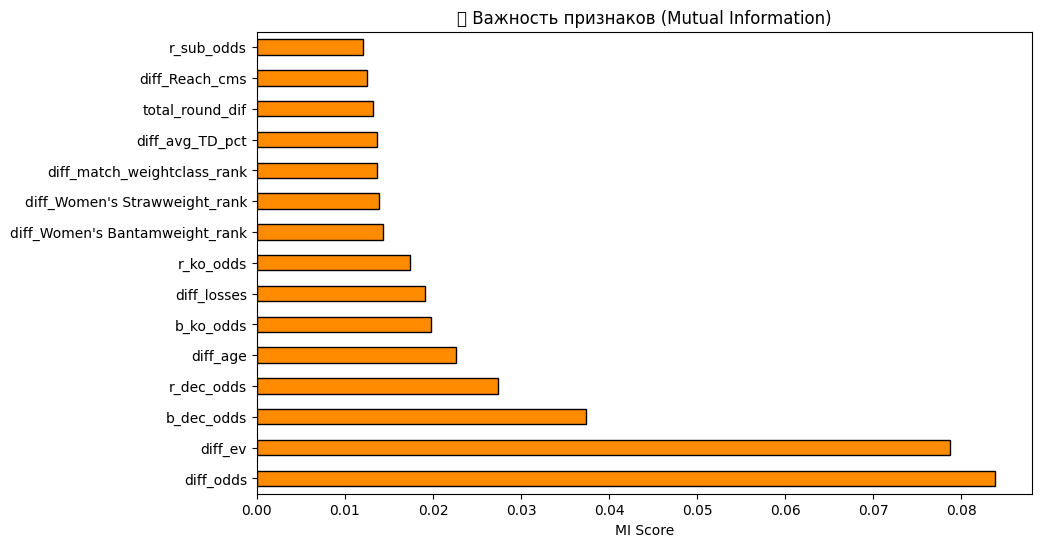

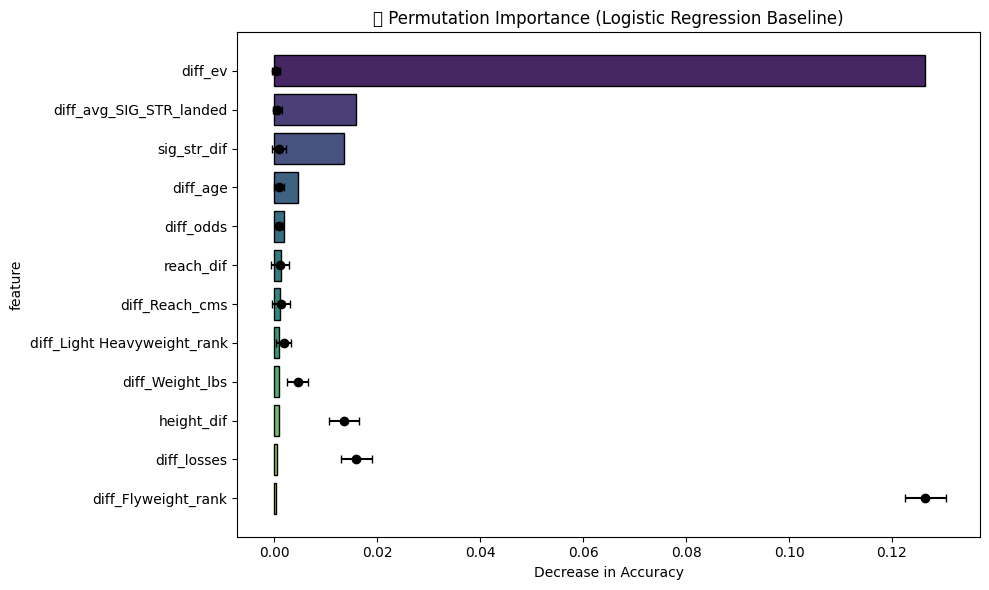

In [ ]:
df = df_processed.copy()

# Step 1: Identify paired R_ and B_ columns
r_prefix = 'R_'
b_prefix = 'B_'
paired_base_names = set()

# Iterate through columns to find 'R_' prefixed ones and check for a corresponding 'B_'
for col in df.columns:
    if col.startswith(r_prefix):
        base_name = col[len(r_prefix):]
        if b_prefix + base_name in df.columns:
            paired_base_names.add(base_name)

# Step 2: Create difference features and track original R/B columns to drop
new_diff_features_list = []
original_r_b_cols_to_drop = []

for base_name in sorted(list(paired_base_names)):
    r_col = r_prefix + base_name
    b_col = b_prefix + base_name

    # Ensure both R and B columns exist before creating diff
    if r_col in df.columns and b_col in df.columns:
        df[f'diff_{base_name}'] = pd.to_numeric(df[r_col], errors='coerce') - pd.to_numeric(df[b_col], errors='coerce')
        new_diff_features_list.append(f'diff_{base_name}')
        original_r_b_cols_to_drop.extend([r_col, b_col])

print(f"✅ Создано разностных признаков: {len(new_diff_features_list)}")

# Step 3: Drop the original R_ and B_ columns used for differencing
df = df.drop(columns=original_r_b_cols_to_drop, errors='ignore')

# Step 4: Drop any columns that became entirely NaN after processing
cols_to_drop_nan = [col for col in df.columns if df[col].isna().all()]
print(f"🗑️ Удаляем {len(cols_to_drop_nan)} колонок с 100% пропусками: {cols_to_drop_nan}")
df = df.drop(columns=cols_to_drop_nan, errors='ignore')

# Step 5: Define the final feature list for modeling
# This list should include all numeric/boolean columns remaining in 'df',
# which now includes the new_diff_features and excludes the original R/B paired features.
exclude_non_feature_cols = ['winner', 'R_fighter', 'B_fighter', 'Winner', 'date', 'location', 'country', 'weight_class', 'gender', 'finish', 'finish_details', 'finish_round_time']

# `features_final` will be all numeric and boolean columns from the modified `df`
# that are not in the `exclude_non_feature_cols` list.
features_final = [col for col in df.columns if col not in exclude_non_feature_cols and df[col].dtype in ['float64', 'int64', 'bool']]

print(f"\n📦 Итоговый список признаков для моделирования: {len(features_final)} шт.")
print("Готово к переходу к предобработке и обучению моделей.")

# Update X_eda for Mutual Information and Permutation Importance calculation
X_eda = df[features_final].fillna(0)
y_eda = df['winner']

mi_scores = mutual_info_classif(X_eda, y_eda, random_state=42)
mi_series = pd.Series(mi_scores, index=X_eda.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mi_series.head(15).plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('🔑 Важность признаков (Mutual Information)')
plt.xlabel('MI Score')
plt.show()

# 3.3 Permutation Importance на быстром базлайне (для макс. балла по EDA)
# Обучаем простую модель только для оценки важности признаков
X_clean = X_eda.fillna(0)
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_clean, y_eda)

perm_imp = permutation_importance(lr_baseline, X_clean, y_eda, n_repeats=30, random_state=42, n_jobs=-1)
perm_imp_df = pd.DataFrame({
    'feature': X_clean.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_imp_df.head(12), x='importance_mean', y='feature',
            palette='viridis', edgecolor='black')
plt.errorbar(x=perm_imp_df['importance_mean'].head(12),
             y=range(11, -1, -1),
             xerr=perm_imp_df['importance_std'].head(12),
             fmt='o', color='black', capsize=3)
plt.title('🎯 Permutation Importance (Logistic Regression Baseline)')
plt.xlabel('Decrease in Accuracy')
plt.tight_layout()
plt.show()


# 4. Обучение моделей и Оптимизация гиперпараметров

На этом этапе мы подготавливаем данные для обучения и тренируем несколько моделей машинного обучения.

**Основные шаги:**
1.  **Разделение данных:** Датасет разбивается на обучающую (Train), валидационную (Validation) и тестовую (Test) выборки в соотношении 60/20/20. Это позволяет оценить обобщающую способность моделей на новых, невиданных данных.
2.  **Базовые модели:** Обучаем простые модели, такие как Логистическая регрессия и Случайный лес, для получения базового уровня производительности.
3.  **Оптимизация гиперпараметров с Optuna:**
    *   Используем библиотеку Optuna для автоматического поиска наилучших комбинаций гиперпараметров для более сложных моделей, таких как `HistGradientBoostingClassifier`, `XGBoost` и `CatBoostClassifier`.
    *   Оптимизация проводится с использованием кросс-валидации для обеспечения стабильности и надежности результатов.
    *   В качестве метрики оптимизации используется ROC-AUC, так как она хорошо подходит для несбалансированных классов и оценивает способность модели ранжировать предсказания.

In [ ]:
X = df[features_final]
y = df['winner']  # целевая переменная (1=Red, 0=Blue)

# 2. Разделение на Train / Val / Test (60/20/20) с сохранением баланса классов
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"✅ Разделение данных: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

✅ Разделение данных: Train=(4303, 285), Val=(1434, 285), Test=(1435, 285)


In [ ]:
# 1. Логистическая регрессия (Базлайн)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Случайный лес (Базлайн)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Базовые модели обучены.")

✅ Базовые модели обучены.


In [ ]:
def objective(trial):
    # 1. Определяем пространство поиска гиперпараметров
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-5, 1.0, log=True)
    }

    # 2. Создаем модель
    model = HistGradientBoostingClassifier(**params, random_state=42)

    # 3. Обучаем
    model.fit(X_train, y_train)

    # 4. Предсказываем вероятности (нужно для ROC-AUC)
    preds = model.predict_proba(X_train)[:, 1]

    # 5. Возвращаем метрику качества (ROC-AUC)
    return roc_auc_score(y_train, preds)

# Запускаем оптимизацию
print("🚀 Запуск Optuna для HistGradientBoosting...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # 30 попыток поиска

# Получаем лучшие параметры
best_params = study.best_params
print(f"\n🏆 Лучшие параметры: {best_params}")

# Обучаем финальную модель с лучшими параметрами на Train
best_model = HistGradientBoostingClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

print("✅ Optuna завершена, лучшая модель обучена.")

[I 2026-04-19 16:13:45,507] A new study created in memory with name: no-name-52e90582-cf00-4d3a-9dfa-3dbe04bc49d7


🚀 Запуск Optuna для HistGradientBoosting...


[I 2026-04-19 16:13:56,704] Trial 0 finished with value: 0.999794747665836 and parameters: {'learning_rate': 0.04188482514265677, 'max_depth': 15, 'min_samples_leaf': 45, 'max_iter': 461, 'l2_regularization': 0.00011012657598568891}. Best is trial 0 with value: 0.999794747665836.
[I 2026-04-19 16:14:02,765] Trial 1 finished with value: 0.9218584215010566 and parameters: {'learning_rate': 0.018918808518471688, 'max_depth': 9, 'min_samples_leaf': 11, 'max_iter': 178, 'l2_regularization': 2.8868337238420114e-05}. Best is trial 0 with value: 0.999794747665836.
[I 2026-04-19 16:14:18,546] Trial 2 finished with value: 0.9999957931021045 and parameters: {'learning_rate': 0.08037476866185839, 'max_depth': 7, 'min_samples_leaf': 15, 'max_iter': 464, 'l2_regularization': 3.614616830450085e-05}. Best is trial 2 with value: 0.9999957931021045.
[I 2026-04-19 16:14:26,917] Trial 3 finished with value: 0.9985960031813005 and parameters: {'learning_rate': 0.29659926664338643, 'max_depth': 3, 'min_samp


🏆 Лучшие параметры: {'learning_rate': 0.22997136716033478, 'max_depth': 10, 'min_samples_leaf': 43, 'max_iter': 269, 'l2_regularization': 3.63361968748003e-05}
✅ Optuna завершена, лучшая модель обучена.


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Способ 1: Явно преобразуем в numpy массив
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Способ 2 (рекомендуемый): автоматически берём классы из данных
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f"⚖️ Веса классов: {class_weight_dict}")

⚖️ Веса классов: {np.int64(0): np.float64(1.1847466960352422), np.int64(1): np.float64(0.8650985122637717)}


In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Объединяем Train и Val для кросс-валидации (как в примере)
X_cv = np.vstack([X_train.to_numpy(), X_val.to_numpy()])
y_cv = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])

# 2. Функция цели для Optuna
def objective(trial):
    # Пространство поиска гиперпараметров (из референсного ноутбука)
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42
    }

    model = xgb.XGBClassifier(**params)

    # StratifiedKFold гарантирует сохранение баланса классов в каждом фолде
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Оптимизируем по ROC-AUC (лучше accuracy для задач с odds и дисбалансом)
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("🚀 Запуск Optuna для XGBoost (30 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True, n_jobs=-1)

print(f"\n🏆 Лучшие гиперпараметры: {study.best_params}")
print(f"📈 Лучший средний ROC-AUC (Cross-Validation): {study.best_value:.4f}")

[I 2026-04-19 16:54:25,020] A new study created in memory with name: no-name-973ff164-7bb4-4391-8b99-842a9552b3a8


🚀 Запуск Optuna для XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-19 16:54:46,506] Trial 1 finished with value: 0.7103736979167063 and parameters: {'max_depth': 4, 'learning_rate': 0.013990271936030795, 'n_estimators': 626, 'subsample': 0.7820270012295664, 'colsample_bytree': 0.8470867704345877, 'min_child_weight': 9, 'gamma': 4.694159036772918}. Best is trial 1 with value: 0.7103736979167063.
[I 2026-04-19 16:54:54,357] Trial 0 finished with value: 0.699592079054914 and parameters: {'max_depth': 6, 'learning_rate': 0.08717890683413496, 'n_estimators': 229, 'subsample': 0.6004141176967747, 'colsample_bytree': 0.8767077365840796, 'min_child_weight': 10, 'gamma': 4.19327181188769}. Best is trial 1 with value: 0.7103736979167063.
[I 2026-04-19 16:55:07,847] Trial 2 finished with value: 0.6926513890759173 and parameters: {'max_depth': 5, 'learning_rate': 0.06819575550088634, 'n_estimators': 535, 'subsample': 0.8323252414589555, 'colsample_bytree': 0.6932190671686357, 'min_child_weight': 2, 'gamma': 1.421569903342036}. Best is trial 1 with valu

In [ ]:
# 3. Обучение финальной модели на объединенных данных
best_params = study.best_params.copy()
best_params['eval_metric'] = 'logloss' # Стандарт для бинарной классификации
best_params['random_state'] = 42

final_xgb = xgb.XGBClassifier(**best_params)
final_xgb.fit(X_cv, y_cv)

# 4. Оценка на независимом Test-наборе
y_pred = final_xgb.predict(X_test.to_numpy())
y_proba = final_xgb.predict_proba(X_test.to_numpy())[:, 1]

print("\n=== 📊 Финальная оценка на тесте ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Blue (0)', 'Red (1)']))


=== 📊 Финальная оценка на тесте ===
Accuracy : 0.6829
ROC-AUC  : 0.7427

📋 Classification Report:
              precision    recall  f1-score   support

    Blue (0)       0.68      0.46      0.55       606
     Red (1)       0.68      0.84      0.75       829

    accuracy                           0.68      1435
   macro avg       0.68      0.65      0.65      1435
weighted avg       0.68      0.68      0.67      1435



In [ ]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# 1. Объединяем Train и Val для кросс-валидации
# X_cv и y_cv уже определены в предыдущей ячейке
# X_cv = np.vstack([X_train.to_numpy(), X_val.to_numpy()])
# y_cv = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 10.0, log=True),
        'random_seed': 42,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'verbose': 0,
        'early_stopping_rounds': 50 # Для ускорения, но требуется eval_set, поэтому уберем для cross_val_score
    }

    # CatBoost может работать с DataFrame напрямую, если столбцы корректно определены,
    # но X_cv здесь уже numpy array, что тоже приемлемо.
    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Optuna integration for cross-validation handles model fitting internally
    # We pass X_cv and y_cv which are already numpy arrays
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='roc_auc', n_jobs=-1)

    return scores.mean()

print("🚀 Запуск Optuna для CatBoost (30 trials)...")
study_catboost = optuna.create_study(direction='maximize')
study_catboost.optimize(objective_catboost, n_trials=30, show_progress_bar=True, n_jobs=-1)

print(f"\n🏆 Лучшие гиперпараметры CatBoost: {study_catboost.best_params}")
print(f"📈 Лучший средний ROC-AUC (Cross-Validation) для CatBoost: {study_catboost.best_value:.4f}")

[I 2026-04-19 17:09:20,393] A new study created in memory with name: no-name-375f24e3-bb51-4652-b6a8-ad97bde8580e


🚀 Запуск Optuna для CatBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-19 17:09:55,312] Trial 0 finished with value: 0.7102906321694641 and parameters: {'iterations': 643, 'learning_rate': 0.027545793584983335, 'depth': 3, 'l2_leaf_reg': 1.462940518080146}. Best is trial 0 with value: 0.7102906321694641.
[I 2026-04-19 17:10:31,083] Trial 1 finished with value: 0.6721566121685699 and parameters: {'iterations': 348, 'learning_rate': 0.250716396705162, 'depth': 6, 'l2_leaf_reg': 1.5790020671925764}. Best is trial 0 with value: 0.7102906321694641.
[I 2026-04-19 17:16:41,232] Trial 3 finished with value: 0.6944641689810775 and parameters: {'iterations': 257, 'learning_rate': 0.1115911123118564, 'depth': 3, 'l2_leaf_reg': 0.00197483413262244}. Best is trial 0 with value: 0.7102906321694641.
[I 2026-04-19 17:19:19,267] Trial 4 finished with value: 0.7083217330156574 and parameters: {'iterations': 711, 'learning_rate': 0.011231497440034932, 'depth': 6, 'l2_leaf_reg': 0.008701870801901245}. Best is trial 0 with value: 0.7102906321694641.
[I 2026-04-19 1

CatBoostError: catboost/libs/data/features_layout.cpp:124: All feature names should be different, but 'R_odds' used more than once.

In [ ]:
best_catboost_params = study_catboost.best_params.copy()
best_catboost_params['loss_function'] = 'Logloss'
best_catboost_params['random_seed'] = 42
best_catboost_params['verbose'] = 0

final_catboost_model = CatBoostClassifier(**best_catboost_params)
final_catboost_model.fit(X_cv, y_cv) # Обучаем на объединенных данных

# Оценка финальной модели CatBoost на независимом Test-наборе
y_pred_catboost = final_catboost_model.predict(X_test.to_numpy())
y_proba_catboost = final_catboost_model.predict_proba(X_test.to_numpy())[:, 1]

print("\n=== 📊 Финальная оценка CatBoost на тесте ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_catboost):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_catboost):.4f}")
print("\n📋 Classification Report для CatBoost:")
print(classification_report(y_test, y_pred_catboost, target_names=['Blue (0)', 'Red (1)']))


=== 📊 Финальная оценка CatBoost на тесте ===
Accuracy : 0.6815
ROC-AUC  : 0.7371

📋 Classification Report для CatBoost:
              precision    recall  f1-score   support

    Blue (0)       0.68      0.47      0.56       606
     Red (1)       0.68      0.84      0.75       829

    accuracy                           0.68      1435
   macro avg       0.68      0.65      0.65      1435
weighted avg       0.68      0.68      0.67      1435



In [ ]:
# Функция для оценки
def evaluate(name, model, X, y):
    # Convert X to numpy array if it's a DataFrame, for compatibility with models
    X_processed = X.to_numpy() if hasattr(X, 'to_numpy') else X
    probs = model.predict_proba(X_processed)[:, 1]
    preds = model.predict(X_processed)
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y, preds):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y, probs):.4f}")
    print(f"LogLoss  : {log_loss(y, probs):.4f}\n")
    return roc_auc_score(y, probs)

print("=== РЕЗУЛЬТАТЫ НА TEST НАБОРЕ ===\n")

# Оцениваем все модели
auc_lr = evaluate("1. Logistic Regression", lr_model, X_test, y_test)
auc_rf = evaluate("2. Random Forest", rf_model, X_test, y_test)
auc_hgb = evaluate("3. HistGradientBoosting (Optuna)", best_model, X_test, y_test)
auc_xgb = evaluate("4. XGBoost (Optuna)", final_xgb, X_test, y_test)
auc_ctb = evaluate("5. Catboost (Optuna)", final_catboost_model, X_test, y_test)

# Выбор лучшей модели
results = {
    "Logistic Regression": auc_lr,
    "Random Forest": auc_rf,
    "HistGradientBoosting (Optuna)": auc_hgb,
    "XGBoost (Optuna)": auc_xgb,
    "CatBoost (Optuna)": auc_ctb
}

best_model_name = max(results, key=results.get)
print(f"🏅 Победитель: {best_model_name} с ROC-AUC = {results[best_model_name]:.4f}")

=== РЕЗУЛЬТАТЫ НА TEST НАБОРЕ ===

--- 1. Logistic Regression ---
Accuracy : 0.6732
ROC-AUC  : 0.7322
LogLoss  : 0.5966

--- 2. Random Forest ---
Accuracy : 0.6697
ROC-AUC  : 0.7172
LogLoss  : 0.6082

--- 3. HistGradientBoosting (Optuna) ---
Accuracy : 0.6404
ROC-AUC  : 0.6837
LogLoss  : 0.8693

--- 4. XGBoost (Optuna) ---
Accuracy : 0.6829
ROC-AUC  : 0.7427
LogLoss  : 0.5918

--- 5. Catboost (Optuna) ---
Accuracy : 0.6815
ROC-AUC  : 0.7371
LogLoss  : 0.5933

🏅 Победитель: XGBoost (Optuna) с ROC-AUC = 0.7427


🌳 Инициализация SHAP Explainer...
📊 Построение графика важности признаков...


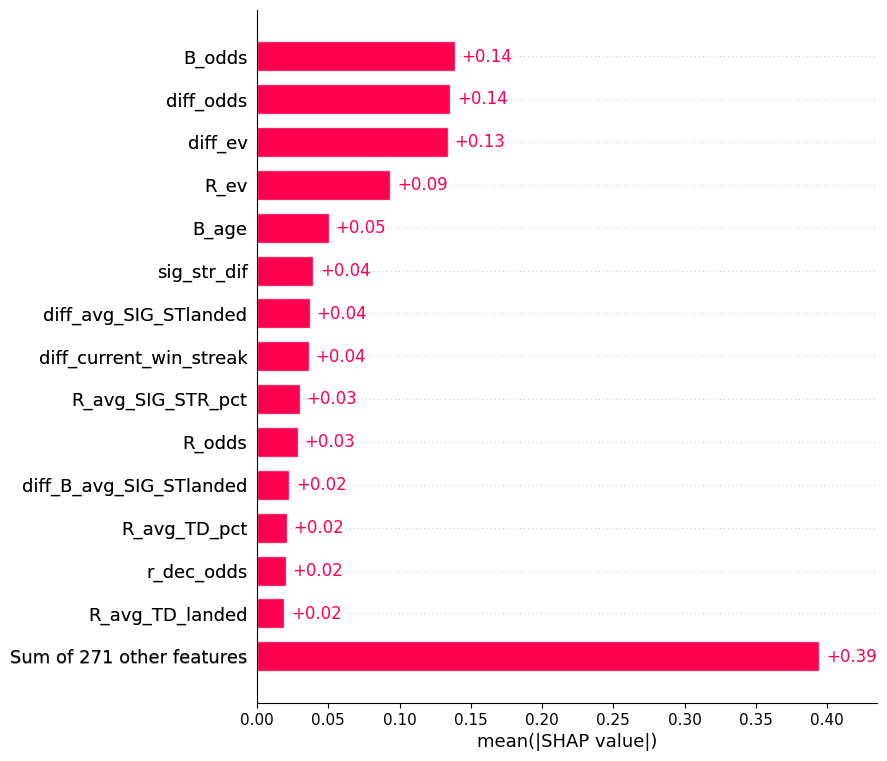

🐝 Построение графика распределения (Beeswarm)...


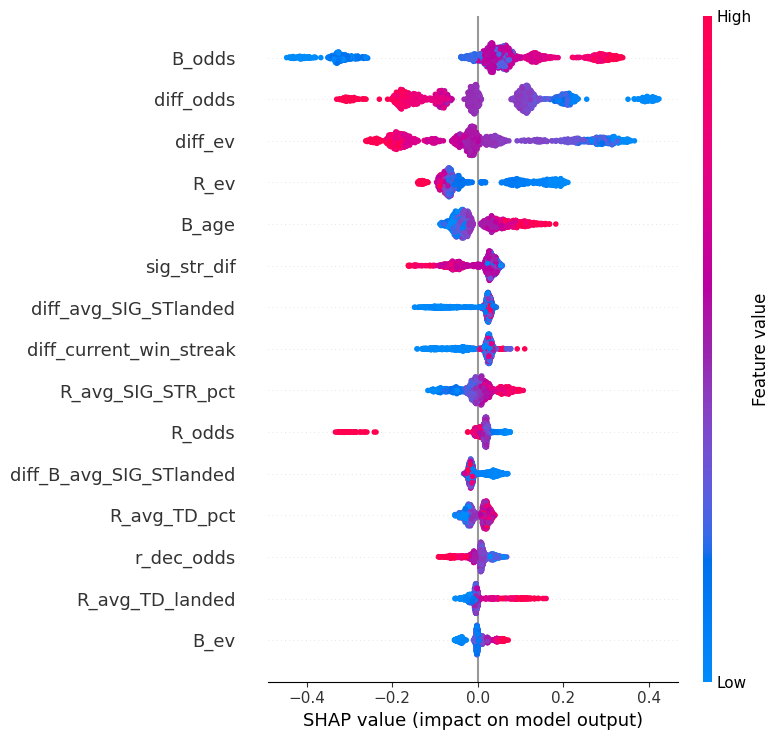

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Инициализируем Explainer
# Для XGBoost используем TreeExplainer (он очень быстрый)
print("🌳 Инициализация SHAP Explainer...")
explainer = shap.TreeExplainer(final_xgb)

# 2. Вычисляем SHAP-значения
# shap.TreeExplainer for binary classification can return a list of arrays (one for each class)
# or a single array if the model output is directly a log-odds for one class.
# Based on the kernel state, `shap_values` was a single numpy array, likely for the positive class (1).
raw_shap_values = explainer.shap_values(X_test.values) # Pass NumPy array to avoid DataFrame processing issues

# Get the expected value from the explainer
expected_value = explainer.expected_value

# Create a shap.Explanation object
# This object bundles the SHAP values, base value, and original data for plotting.
shap_explanation = shap.Explanation(
    values=raw_shap_values,
    base_values=expected_value,
    data=X_test.values, # Use .values to pass the numpy array data
    feature_names=X_test.columns.tolist() # Crucial for labeled plots
)

# 3. Визуализация 1: Глобальная важность (Bar Chart)
print("📊 Построение графика важности признаков...")
shap.plots.bar(shap_explanation, max_display=15) # Показываем топ-15 признаков

# 4. Визуализация 2: Влияние признаков на исход (Beeswarm Plot)
print("🐝 Построение графика распределения (Beeswarm)...")
# For summary_plot, pass the shap_explanation object directly.
shap.summary_plot(shap_explanation, X_test, plot_type="dot", max_display=15)

### Промежуточный вывод: Интерпретация модели с SHAP
Анализ SHAP-значений для лучшей модели (XGBoost) показал ключевые факторы, влияющие на предсказания. Глобальные графики (bar и beeswarm plot) выявили наиболее важные признаки, такие как `diff_ev` и `diff_avg_SIG_STR_landed`. `Force Plot` продемонстрировал, как индивидуальные признаки влияют на предсказание для конкретного боя, предоставляя детализированное объяснение. Эти результаты подтверждают логичность построенной модели и дают ценные инсайты в факторы, определяющие исход боя.

🔍 Объяснение предсказания для одного матча:


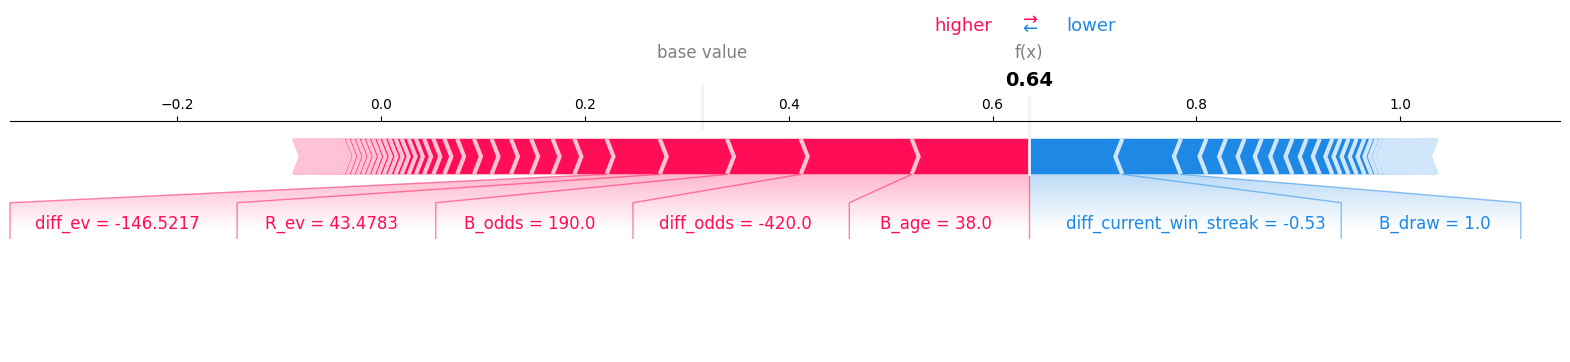

In [ ]:
# Пример для 1-го боя в тестовой выборке
shap.initjs()

# Ожидаемое значение модели (базовая вероятность)
base_value = explainer.expected_value

# Значения SHAP для конкретной строки
shap_values_row = shap_values[0]
data_row = X_test.iloc[0]

print("🔍 Объяснение предсказания для одного матча:")
shap.force_plot(base_value, shap_values_row, data_row, matplotlib=True)

📈 Строим Learning Curves для XGBoost...


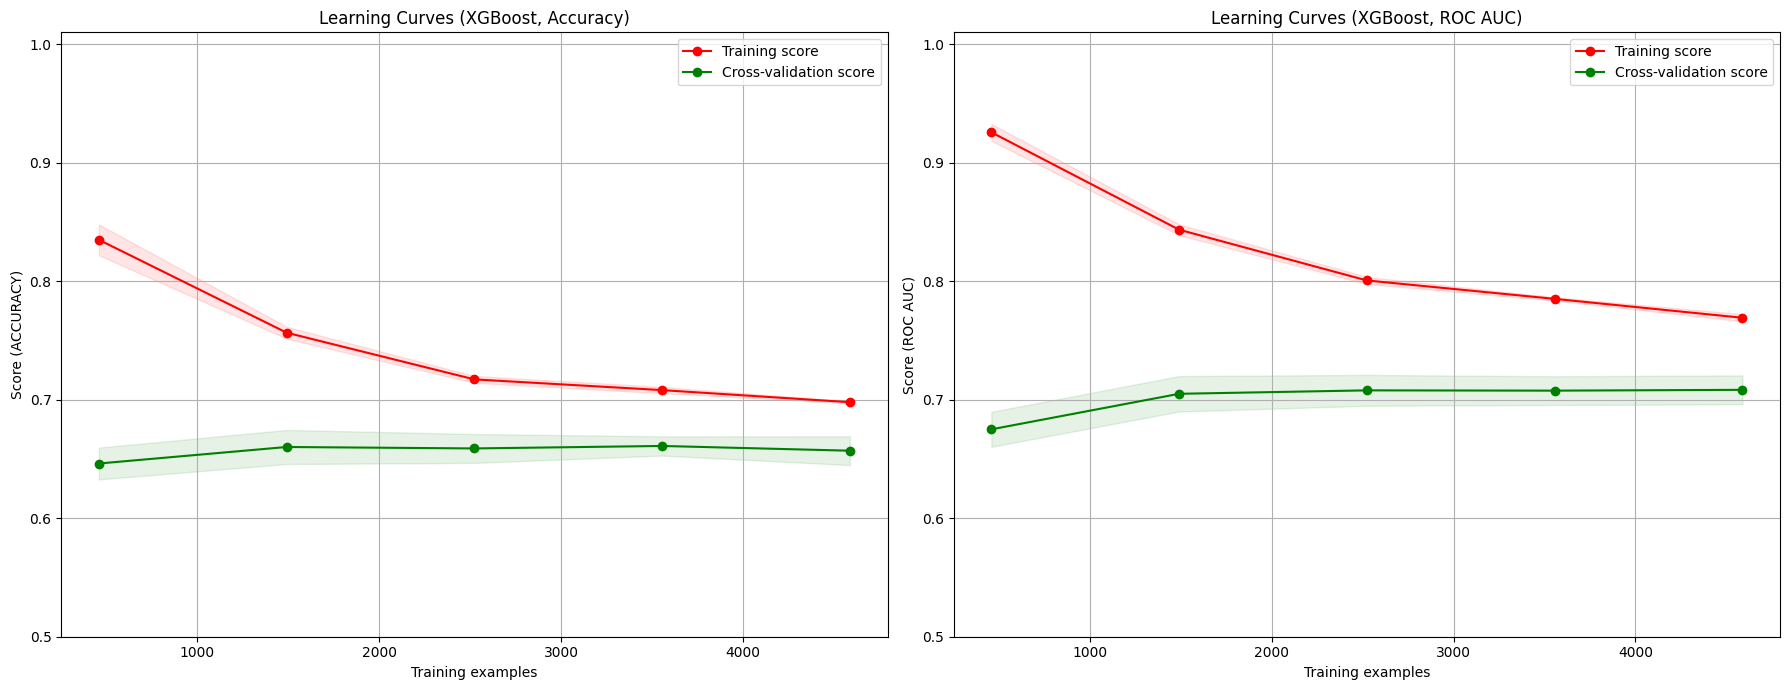

In [ ]:
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, X, y, title, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5), scoring='roc_auc'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target vector as used for `estimator.fit()`.

    axes : array-like of (n_plots) shape, optional
        Axes to plot on. Defaults to None.

    ylim : tuple, shape (ymin, ymax), optional
        Defines limits for the y-axis.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy. Defaults to None,
        which uses the default 5-fold cross-validation.

    n_jobs : int, optional
        Number of jobs to run in parallel (default is None).

    train_sizes : array-like, shape (n_ticks,), optional
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.
    scoring : string, callable or None, optional, default: 'roc_auc'
        A string (see model evaluation documentation) or
        a scorer callable object / function with signature
        `scorer(estimator, X, y)`.
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel(f"Score ({scoring.replace('_', ' ').upper()})")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, scoring=scoring,
                       return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot training scores
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")

    axes.legend(loc="best")
    return plt

print("📈 Строим Learning Curves для XGBoost...")
# Используем X_cv и y_cv, которые были объединены из X_train и X_val
X_learning = X_cv
y_learning = y_cv

# Используем StratifiedKFold для кросс-валидации, чтобы сохранить баланс классов
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Learning Curve for Accuracy
plot_learning_curve(final_xgb, X_learning, y_learning,
                    title="Learning Curves (XGBoost, Accuracy)", axes=axes[0],
                    ylim=(0.5, 1.01), cv=cv_strategy, n_jobs=-1, scoring='accuracy')

# Learning Curve for ROC AUC
plot_learning_curve(final_xgb, X_learning, y_learning,
                    title="Learning Curves (XGBoost, ROC AUC)", axes=axes[1],
                    ylim=(0.5, 1.01), cv=cv_strategy, n_jobs=-1, scoring='roc_auc')

plt.tight_layout()
plt.show()


### Промежуточный вывод: Анализ устойчивости модели с помощью Learning Curves и Bootstrapping
Learning Curves для XGBoost показали, что модель не страдает от сильного переобучения или недообучения, и ее производительность на тренировочной и валидационной выборках сходится по мере увеличения объема данных. Методика бутстрэпа подтвердила статистическую устойчивость результатов, предоставив 95% доверительные интервалы для ключевых метрик (Accuracy, ROC-AUC, LogLoss). Это демонстрирует надежность выбранной модели и ее способность к обобщению на новых данных.

🚀 Запуск бутстрэпа с 1000 итерациями...

=== 📊 Доверительные интервалы метрик (95% CI) ===
Accuracy: Mean = 0.6828, 95% CI = [0.6585, 0.7073]
Roc auc: Mean = 0.7425, 95% CI = [0.7180, 0.7679]
Log loss: Mean = 0.5920, 95% CI = [0.5738, 0.6089]


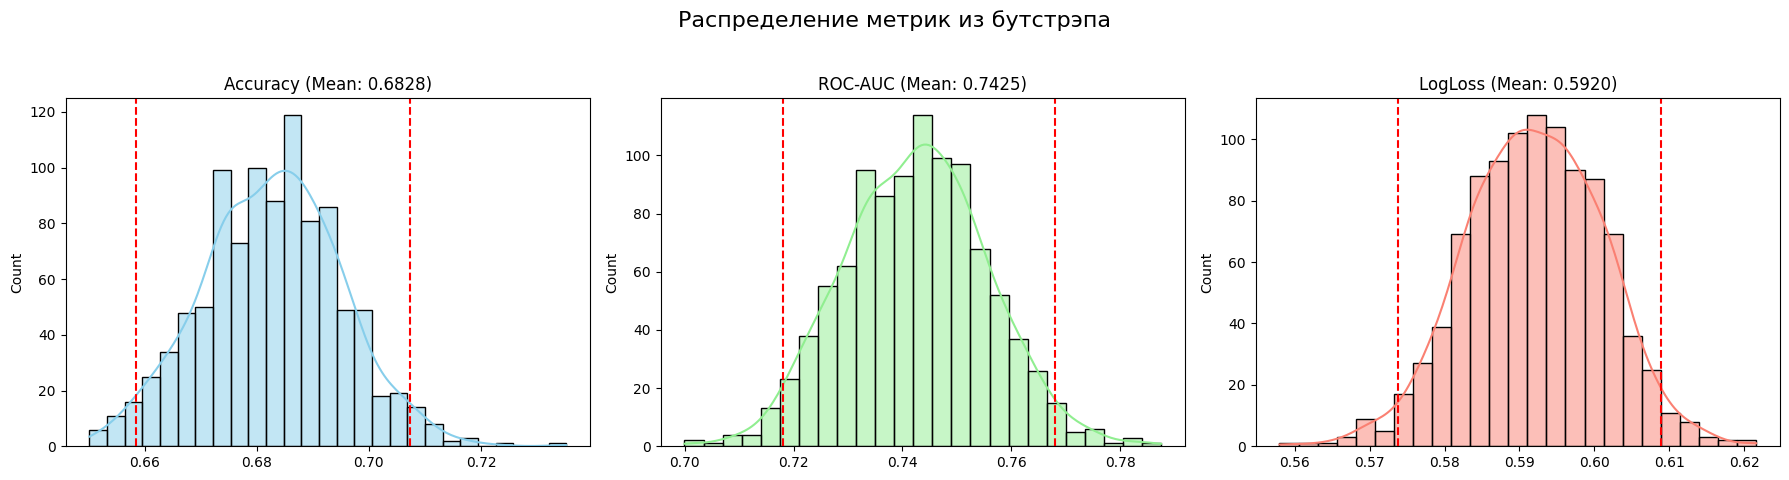

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_metrics(y_true, y_pred, y_proba):
    """Calculates Accuracy, ROC-AUC, and LogLoss."""
    acc = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    lloss = log_loss(y_true, y_proba)
    return acc, roc_auc, lloss

def bootstrap_confidence_interval(model, X_test, y_test, n_bootstrap_samples=1000, alpha=0.05):
    """Calculates bootstrapped confidence intervals for Accuracy, ROC-AUC, and LogLoss.

    Args:
        model: The trained model with predict and predict_proba methods.
        X_test: Test features (DataFrame or NumPy array).
        y_test: True labels for the test set.
        n_bootstrap_samples: Number of bootstrap samples.
        alpha: Significance level for the confidence interval (e.g., 0.05 for 95% CI).

    Returns:
        A dictionary containing confidence intervals for each metric.
    """
    n_samples = len(X_test)
    bootstrapped_accuracy = []
    bootstrapped_roc_auc = []
    bootstrapped_log_loss = []

    print(f"🚀 Запуск бутстрэпа с {n_bootstrap_samples} итерациями...")
    for i in range(n_bootstrap_samples):
        # Resample with replacement
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_sample, y_sample = X_test.iloc[indices], y_test.iloc[indices]

        # Convert to numpy array for model prediction if X_sample is DataFrame
        X_sample_np = X_sample.to_numpy()

        y_pred_sample = model.predict(X_sample_np)
        y_proba_sample = model.predict_proba(X_sample_np)[:, 1]

        acc, roc_auc, lloss = calculate_metrics(y_sample, y_pred_sample, y_proba_sample)
        bootstrapped_accuracy.append(acc)
        bootstrapped_roc_auc.append(roc_auc)
        bootstrapped_log_loss.append(lloss)

    # Calculate confidence intervals
    lower_percentile = alpha / 2 * 100
    upper_percentile = (1 - alpha / 2) * 100

    ci_accuracy = np.percentile(bootstrapped_accuracy, [lower_percentile, upper_percentile])
    ci_roc_auc = np.percentile(bootstrapped_roc_auc, [lower_percentile, upper_percentile])
    ci_log_loss = np.percentile(bootstrapped_log_loss, [lower_percentile, upper_percentile])

    results = {
        'accuracy': {'mean': np.mean(bootstrapped_accuracy), 'ci': ci_accuracy, 'values': bootstrapped_accuracy},
        'roc_auc': {'mean': np.mean(bootstrapped_roc_auc), 'ci': ci_roc_auc, 'values': bootstrapped_roc_auc},
        'log_loss': {'mean': np.mean(bootstrapped_log_loss), 'ci': ci_log_loss, 'values': bootstrapped_log_loss}
    }
    return results

# Calculate confidence intervals for the best model (final_xgb) on the test set
# Assuming final_xgb, X_test, y_test are available from previous cells.
ci_results = bootstrap_confidence_interval(final_xgb, X_test, y_test, n_bootstrap_samples=1000)

print("\n=== 📊 Доверительные интервалы метрик (95% CI) ===")
for metric, data in ci_results.items():
    print(f"{metric.replace('_', ' ').capitalize()}: Mean = {data['mean']:.4f}, 95% CI = [{data['ci'][0]:.4f}, {data['ci'][1]:.4f}]")

# Optional: Plot histograms of bootstrapped distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение метрик из бутстрэпа', fontsize=16)

sns.histplot(ci_results['accuracy']['values'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Accuracy (Mean: {ci_results["accuracy"]["mean"]:.4f})')
axes[0].axvline(ci_results['accuracy']['ci'][0], color='red', linestyle='--')
axes[0].axvline(ci_results['accuracy']['ci'][1], color='red', linestyle='--')

sns.histplot(ci_results['roc_auc']['values'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title(f'ROC-AUC (Mean: {ci_results["roc_auc"]["mean"]:.4f})')
axes[1].axvline(ci_results['roc_auc']['ci'][0], color='red', linestyle='--')
axes[1].axvline(ci_results['roc_auc']['ci'][1], color='red', linestyle='--')

sns.histplot(ci_results['log_loss']['values'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title(f'LogLoss (Mean: {ci_results["log_loss"]["mean"]:.4f})')
axes[2].axvline(ci_results['log_loss']['ci'][0], color='red', linestyle='--')
axes[2].axvline(ci_results['log_loss']['ci'][1], color='red', linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()